# Clustering de Prescriptores — `doctors_aggregated.csv`

Análisis de segmentación de prescriptores usando datos **ya agregados a nivel doctor** (~21k filas).

### Algoritmos aplicados (todos con $k=3$)
| Algoritmo | Representante | Formas | Outliers |
|---|---|---|---|
| **K-Means** | Centroide (sintético) | Esféricas | No maneja |
| **K-Medoids (PAM)** | Medoide (punto real) | Esféricas | Robusto |
| **Hierarchical (Ward)** | Dendrograma → corte | Esféricas | No maneja |
| **GMM** | Media de componente | Elipsoidales | Probabilístico |

### Diseño experimental
- **Muestra única** compartida por todos los algoritmos → comparación justa
- **`random_state=42`** global para reproducibilidad
- **RobustScaler** (resistente a outliers) + `log1p` en variables sesgadas
- **$k \geq 3$** como restricción de negocio (2 segmentos no es accionable)
- Comparativa **$k_{\text{óptimo}}$ vs $k=3$** con tabla de métricas

## 1. Imports y configuración global

In [34]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score, pairwise_distances)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# ── Configuración global ──
SEED = 42
np.random.seed(SEED)

# ── K-Medoids (PAM) — implementación compatible con NumPy 2.x ──
class KMedoids:
    """PAM K-Medoids: los medoides son puntos reales del dataset."""
    def __init__(self, n_clusters=3, random_state=42, max_iter=200):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.max_iter = max_iter

    def fit_predict(self, X):
        rng = np.random.RandomState(self.random_state)
        n = len(X)
        medoid_idx = rng.choice(n, self.n_clusters, replace=False)
        for _ in range(self.max_iter):
            D = pairwise_distances(X, X[medoid_idx], metric='euclidean')
            labels = np.argmin(D, axis=1)
            new_med = []
            for c in range(self.n_clusters):
                pts = np.where(labels == c)[0]
                if len(pts) == 0:
                    new_med.append(medoid_idx[c])
                    continue
                Dsub = pairwise_distances(X[pts], X[pts])
                new_med.append(pts[np.argmin(Dsub.sum(axis=1))])
            new_med = np.array(new_med)
            if np.array_equal(np.sort(new_med), np.sort(medoid_idx)):
                break
            medoid_idx = new_med
        self.medoid_indices_ = medoid_idx
        D = pairwise_distances(X, X[medoid_idx])
        self.labels_ = np.argmin(D, axis=1)
        return self.labels_

# ── Paleta y estilo ──
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52',
           '#8172B3', '#937860', '#DA8BC3', '#8C8C8C']

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

print('Librerías cargadas — random_state global:', SEED)

Librerías cargadas — random_state global: 42


## 2. Carga y exploración de datos

In [35]:
df_raw = pd.read_csv('doctors_aggregated.csv')
print(f'Shape: {df_raw.shape}')
print(f'Filas (doctores únicos): {len(df_raw):,}')
print(f'Columnas: {df_raw.columns.shape[0]}')
print(f'Valores nulos totales: {df_raw.isnull().sum().sum():,}')
print()

print('Distribución ATSEG (segmentación previa):')
print(df_raw['ATSEG_first'].value_counts(dropna=False))
print()

# Tipos de columnas
num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
non_num  = [c for c in df_raw.columns if c not in num_cols]
print(f'Columnas numéricas: {len(num_cols)}')
print(f'Columnas no numéricas: {non_num}')
df_raw.head(3)

Shape: (20931, 151)
Filas (doctores únicos): 20,931
Columnas: 151
Valores nulos totales: 0

Distribución ATSEG (segmentación previa):
ATSEG_first
0        9032
SEG_A    6406
SEG_B    3349
SEG_C    2144
Name: count, dtype: int64

Columnas numéricas: 148
Columnas no numéricas: ['ATSEG_first', 'WEEK_ID_first', 'WEEK_ID_last']


,NUEVO_ID,UC_TRX_sum,UC_TRX_mean,UC_TRX_max,ORAL_TRX_sum,ORAL_TRX_mean,ORAL_TRX_max,IL23_TRX_sum,IL23_TRX_mean,IL23_TRX_max,...,STS_OTHER_STS_first,STATE_7_first,STATE_8_first,"(1940, 1960]_first","(1960, 1980]_first","(1980, 2000]_first",ATSEG_first,WEEK_ID_first,WEEK_ID_last,WEEK_ID_count
0,1,3.873379,0.045039,0.677346,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0,2025-08-22,2025-04-25,86
1,2,19.603356,0.227946,2.125095,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,2025-02-28,2024-08-23,86
2,3,63.040427,0.733028,2.520976,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,SEG_A,2025-05-16,2024-12-27,86


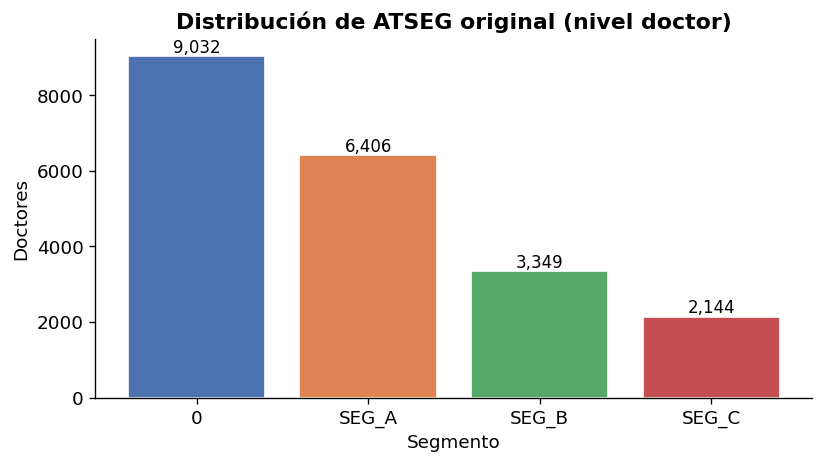

In [36]:
# Visualización: distribución ATSEG
fig, ax = plt.subplots(figsize=(7, 4))
vc = df_raw['ATSEG_first'].value_counts(dropna=False).sort_index()
bars = ax.bar(vc.index.astype(str), vc.values, color=PALETTE[:len(vc)], edgecolor='white')
for bar, v in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{v:,}', ha='center', fontsize=10)
ax.set_title('Distribución de ATSEG original (nivel doctor)', fontweight='bold')
ax.set_ylabel('Doctores')
ax.set_xlabel('Segmento')
plt.tight_layout()
plt.show()

## 3. Selección de features y preprocesamiento

**Columnas excluidas del clustering:**
- `NUEVO_ID` — identificador
- `WEEK_ID_first`, `WEEK_ID_last`, `WEEK_ID_count` — temporales
- `ATSEG_first` — etiqueta de referencia (se usa para validación externa, no como feature)
- `SPEC_*`, `STATE_*`, `(1940,1960]_first`, etc. — dummies categóricas (se excluyen del escalado numérico)

**Preprocesamiento:**
1. `log1p` en variables de prescripción muy sesgadas (skewness > 2)
2. `RobustScaler` — usa mediana e IQR, resistente a outliers
3. PCA(2) y t-SNE(2) para visualización

In [37]:
# ── Columnas a excluir ──
DROP_COLS = ['NUEVO_ID', 'WEEK_ID_first', 'WEEK_ID_last', 'WEEK_ID_count', 'ATSEG_first']

# Identificar dummies categóricas (SPEC_*, STATE_*, STS_*, age brackets)
cat_dummies = [c for c in df_raw.columns
               if c.startswith(('SPEC_', 'STATE_', 'STS_'))
               or c.startswith('(')]

print(f'Dummies categóricas ({len(cat_dummies)}): {cat_dummies}')

# Features numéricas continuas para clustering
FEATURES = [c for c in df_raw.select_dtypes(include=[np.number]).columns
            if c not in DROP_COLS and c not in cat_dummies]

print(f'\nFeatures numéricas seleccionadas: {len(FEATURES)}')

# Guardar ATSEG para validación cruzada posterior
atseg = df_raw['ATSEG_first'].copy()

# Extraer subconjunto numérico
df_feat = df_raw[FEATURES].copy()
print(f'Shape df_feat: {df_feat.shape}')
print(f'Nulos: {df_feat.isnull().sum().sum()}')

Dummies categóricas (18): ['SPEC_GE_first', 'SPEC_GPFM_first', 'SPEC_IM_first', 'SPEC_NRP_first', 'SPEC_OTHER_SPEC_first', 'SPEC_PHA_first', 'STATE_1_first', 'STATE_2_first', 'STATE_3_first', 'STATE_4_first', 'STATE_5_first', 'STATE_6_first', 'STS_OTHER_STS_first', 'STATE_7_first', 'STATE_8_first', '(1940, 1960]_first', '(1960, 1980]_first', '(1980, 2000]_first']

Features numéricas seleccionadas: 128
Shape df_feat: (20931, 128)
Nulos: 0


In [38]:
# ── log1p en columnas con skewness alta ──
skew_vals = df_feat.skew()
high_skew = skew_vals[skew_vals.abs() > 2].index.tolist()
print(f'Columnas con |skewness| > 2: {len(high_skew)}')
for col in high_skew:
    # log1p solo aplica a valores >= 0; para columnas con negativos, desplazar primero
    col_min = df_feat[col].min()
    if col_min < 0:
        df_feat[col] = np.log1p(df_feat[col] - col_min)
    else:
        df_feat[col] = np.log1p(df_feat[col])

print('Skewness después de log1p (top 10):')
print(df_feat[high_skew].skew().sort_values(ascending=False).head(10))

Columnas con |skewness| > 2: 104
Skewness después de log1p (top 10):
NBRx_RATIO_mean                  26.109024
NBRx_RATIO_max                   22.469910
N_CLMBRAND1_NEW_mean             15.461920
N_CLMBRAND1_NEW_sum              14.691741
COPAY_mean                        9.926508
BRAND1_NRX_mean                   9.660846
BRAND1_TRX_mean                   9.091375
N_CLMBRAND4_NEW_TO_BRAND_mean     9.008839
N_CLMBRAND1_mean                  8.939659
SPK_mean                          8.784576
dtype: float64


In [41]:
# ── RobustScaler ──
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_feat)
print(f'X_scaled shape: {X_scaled.shape}')

# ── PCA (2 componentes) para visualización ──
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)
print(f'Varianza explicada por 2 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%')
print(f'  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%')

# ── t-SNE (2 componentes) — sobre PCA(30) para acelerar ──
pca_30 = PCA(n_components=min(30, X_scaled.shape[1]), random_state=SEED)
X_pca30 = pca_30.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=SEED, perplexity=40, n_iter=1000, init='pca')
X_tsne = tsne.fit_transform(X_pca30)
print(f't-SNE completado sobre {X_pca30.shape[1]} PCs previos')

X_scaled shape: (20931, 128)
Varianza explicada por 2 PCs: 73.3%
  PC1: 65.8%  PC2: 7.5%


TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

In [ ]:
# ── Visualizar PCA y t-SNE coloreados por ATSEG ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Proyecciones 2D coloreadas por ATSEG original', fontsize=14, fontweight='bold')

atseg_labels = atseg.fillna('Sin ATSEG')
atseg_order = ['SEG_A', 'SEG_B', 'SEG_C', 'Sin ATSEG']
atseg_colors = {s: PALETTE[i] for i, s in enumerate(atseg_order)}

for proj, ax, title in [(X_pca, axes[0], 'PCA'), (X_tsne, axes[1], 't-SNE')]:
    for seg in atseg_order:
        mask = atseg_labels == seg
        alpha = 0.15 if seg == 'Sin ATSEG' else 0.4
        ax.scatter(proj[mask, 0], proj[mask, 1], s=5, alpha=alpha,
                   color=atseg_colors[seg], label=f'{seg} ({mask.sum():,})')
    ax.set_title(title)
    ax.set_xlabel(f'{title}1'); ax.set_ylabel(f'{title}2')
    ax.legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.show()

## 4. Selección del $k$ óptimo (restricción $k \geq 3$)

Se evalúa el método del Codo (inercia) y Silhouette Score para K-Means y K-Medoids sobre el rango $k \in [3, 8]$.

> **Nota:** $k=2$ se excluye explícitamente — una segmentación de 2 grupos no es accionable para el negocio.

In [ ]:
# ── K-Means: Elbow + Silhouette ──
K_RANGE = range(3, 9)
km_inertias, km_silhouettes, km_db, km_ch = [], [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labs = km.fit_predict(X_scaled)
    km_inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labs, sample_size=5000, random_state=SEED)
    km_silhouettes.append(sil)
    km_db.append(davies_bouldin_score(X_scaled, labs))
    km_ch.append(calinski_harabasz_score(X_scaled, labs))
    print(f'  K-Means k={k}  inercia={km.inertia_:>12,.0f}  silhouette={sil:.4f}')

K_OPT_KM = list(K_RANGE)[np.argmax(km_silhouettes)]
print(f'\n→ k óptimo K-Means (por Silhouette): {K_OPT_KM}')

In [ ]:
# ── K-Medoids: Silhouette por k (muestra 10k para velocidad) ──
KMED_EVAL_SIZE = 10_000
idx_kmed_eval = np.random.choice(len(X_scaled), KMED_EVAL_SIZE, replace=False)
X_kmed_eval = X_scaled[idx_kmed_eval]

kmed_silhouettes = []
for k in K_RANGE:
    kmed = KMedoids(n_clusters=k, random_state=SEED, max_iter=150)
    labs = kmed.fit_predict(X_kmed_eval)
    sil = silhouette_score(X_kmed_eval, labs, sample_size=3000, random_state=SEED)
    kmed_silhouettes.append(sil)
    print(f'  K-Medoids k={k}  silhouette={sil:.4f}')

K_OPT_KMED = list(K_RANGE)[np.argmax(kmed_silhouettes)]
print(f'\n→ k óptimo K-Medoids (por Silhouette): {K_OPT_KMED}')

In [ ]:
# ── Gráficas: Elbow + Silhouette ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Selección de $k$ óptimo ($k \\geq 3$)', fontsize=14, fontweight='bold')

# Elbow (K-Means)
axes[0].plot(list(K_RANGE), km_inertias, 'o-', color='#4C72B0', lw=2, ms=7)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Método del Codo — K-Means'); axes[0].set_xticks(list(K_RANGE))
axes[0].grid(True, alpha=0.3)

# Silhouette K-Means
axes[1].plot(list(K_RANGE), km_silhouettes, 'o-', color='#DD8452', lw=2, ms=7, label='K-Means')
axes[1].axvline(x=K_OPT_KM, color='red', ls='--', alpha=0.6, label=f'Mejor k={K_OPT_KM}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette — K-Means'); axes[1].set_xticks(list(K_RANGE))
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Silhouette K-Medoids
axes[2].plot(list(K_RANGE), kmed_silhouettes, 's-', color='#55A868', lw=2, ms=7, label='K-Medoids')
axes[2].axvline(x=K_OPT_KMED, color='red', ls='--', alpha=0.6, label=f'Mejor k={K_OPT_KMED}')
axes[2].set_xlabel('k'); axes[2].set_ylabel('Silhouette Score')
axes[2].set_title('Silhouette — K-Medoids (10k muestra)'); axes[2].set_xticks(list(K_RANGE))
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.1 Tabla comparativa: $k_{\text{óptimo}}$ vs $k=3$

In [ ]:
# ── Métricas K-Means: k_opt vs k=3 ──
def compute_metrics(X, labels):
    return {
        'Silhouette': silhouette_score(X, labels, sample_size=5000, random_state=SEED),
        'Davies-Bouldin': davies_bouldin_score(X, labels),
        'Calinski-Harabasz': calinski_harabasz_score(X, labels),
    }

# K-Means k=3
km3 = KMeans(n_clusters=3, random_state=SEED, n_init=10)
labs_km3 = km3.fit_predict(X_scaled)
m_km3 = compute_metrics(X_scaled, labs_km3)

# K-Means k_opt
km_opt = KMeans(n_clusters=K_OPT_KM, random_state=SEED, n_init=10)
labs_km_opt = km_opt.fit_predict(X_scaled)
m_km_opt = compute_metrics(X_scaled, labs_km_opt)

# K-Medoids k=3 (sobre muestra)
kmed3 = KMedoids(n_clusters=3, random_state=SEED, max_iter=150)
labs_kmed3 = kmed3.fit_predict(X_kmed_eval)
m_kmed3 = compute_metrics(X_kmed_eval, labs_kmed3)

# K-Medoids k_opt
kmed_opt_model = KMedoids(n_clusters=K_OPT_KMED, random_state=SEED, max_iter=150)
labs_kmed_opt = kmed_opt_model.fit_predict(X_kmed_eval)
m_kmed_opt = compute_metrics(X_kmed_eval, labs_kmed_opt)

# Tabla resumen
comp_df = pd.DataFrame([
    {'Algoritmo': 'K-Means',   'k': 3,          **m_km3},
    {'Algoritmo': 'K-Means',   'k': K_OPT_KM,   **m_km_opt},
    {'Algoritmo': 'K-Medoids', 'k': 3,           **m_kmed3},
    {'Algoritmo': 'K-Medoids', 'k': K_OPT_KMED,  **m_kmed_opt},
])
comp_df['k'] = comp_df['k'].astype(int)
comp_df = comp_df.round(4)

print('Comparativa k_óptimo vs k=3:')
print(comp_df.to_string(index=False))
comp_df

## 5. Clustering con $k=3$ — Cuatro algoritmos

Se fuerza $k=3$ en todos los algoritmos para una comparación homogénea.

### 5.1 K-Means

In [ ]:
K = 3  # Restricción de negocio

# ── 5.1  K-Means ──
kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=20)
labels_kmeans = kmeans.fit_predict(X_scaled)
metrics_kmeans = compute_metrics(X_scaled, labels_kmeans)
centroids_kmeans = kmeans.cluster_centers_  # en espacio escalado

# Centroides en PCA y t-SNE para plot
centroids_pca  = pca.transform(centroids_kmeans)
centroids_tsne_approx = np.array([X_tsne[labels_kmeans == c].mean(axis=0) for c in range(K)])

print(f'K-Means (k={K})')
for m, v in metrics_kmeans.items():
    print(f'  {m}: {v:.4f}')
print(f'\nDistribución: {dict(zip(*np.unique(labels_kmeans, return_counts=True)))}')

# Features clave para heatmaps
TOP_FEAT = ['UC_TRX_sum', 'ORAL_TRX_sum', 'IL23_TRX_sum',
            'BRAND1_TRX_sum', 'BRAND2_TRX_sum',
            'RTE_sum', 'SAMPLES_sum', 'DETAILS_sum',
            'ENGAGEMENT_SCORE_sum', 'TOTAL_TRX_sum']
# Solo usar las que existen en FEATURES
TOP_FEAT = [f for f in TOP_FEAT if f in FEATURES]

### 5.2 K-Medoids (PAM)

In [ ]:
# ── 5.2  K-Medoids (PAM) — dataset completo (21k es factible) ──
kmedoids = KMedoids(n_clusters=K, random_state=SEED, max_iter=200)
labels_kmedoids = kmedoids.fit_predict(X_scaled)
metrics_kmedoids = compute_metrics(X_scaled, labels_kmedoids)

# Medoides: puntos reales del dataset
medoid_indices = kmedoids.medoid_indices_
medoids_pca  = X_pca[medoid_indices]
medoids_tsne = X_tsne[medoid_indices]

print(f'K-Medoids (k={K})')
for m, v in metrics_kmedoids.items():
    print(f'  {m}: {v:.4f}')
print(f'\nDistribución: {dict(zip(*np.unique(labels_kmedoids, return_counts=True)))}')
print(f'Índices de medoides: {medoid_indices}')

### 5.3 Hierarchical Clustering (Ward)

In [ ]:
# ── 5.3  Hierarchical Clustering (Ward, corte en k=3) ──
# Linkage sobre PCA(30) para reducir dimensionalidad y acelerar
Z = linkage(X_pca30, method='ward', metric='euclidean')
labels_hier = fcluster(Z, t=K, criterion='maxclust') - 1  # 0-indexed

metrics_hier = compute_metrics(X_scaled, labels_hier)

print(f'Hierarchical Ward (k={K})')
for m, v in metrics_hier.items():
    print(f'  {m}: {v:.4f}')
print(f'\nDistribución: {dict(zip(*np.unique(labels_hier, return_counts=True)))}')

# Dendrograma (truncado a 30 hojas)
fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90,
           leaf_font_size=9, color_threshold=Z[-(K-1), 2], ax=ax)
ax.axhline(y=Z[-(K-1), 2], color='red', ls='--', alpha=0.7, label=f'Corte k={K}')
ax.set_title(f'Dendrograma Ward (truncado a 30 hojas, corte en k={K})', fontweight='bold')
ax.set_xlabel('Subcluster'); ax.set_ylabel('Distancia')
ax.legend()
plt.tight_layout()
plt.show()

### 5.4 Gaussian Mixture Models (GMM)

In [ ]:
# ── 5.4  GMM (3 componentes) ──
gmm = GaussianMixture(n_components=K, random_state=SEED, covariance_type='full', n_init=5)
labels_gmm = gmm.fit_predict(X_scaled)
metrics_gmm = compute_metrics(X_scaled, labels_gmm)

# Medias de componentes → PCA/t-SNE
gmm_means = gmm.means_  # (K, n_features) en espacio escalado
gmm_means_pca = pca.transform(gmm_means)
gmm_means_tsne_approx = np.array([X_tsne[labels_gmm == c].mean(axis=0) for c in range(K)])

print(f'GMM (k={K})')
for m, v in metrics_gmm.items():
    print(f'  {m}: {v:.4f}')
print(f'\nDistribución: {dict(zip(*np.unique(labels_gmm, return_counts=True)))}')
print(f'BIC: {gmm.bic(X_scaled):.1f}  |  AIC: {gmm.aic(X_scaled):.1f}')

## 6. Visualización de clústeres con centroides y medoides

Scatter plots en PCA y t-SNE para los 4 algoritmos. Se marcan explícitamente:
- **Centroides** (K-Means, GMM): media sintética de cada cluster
- **Medoides** (K-Medoids): observaciones reales representativas

In [ ]:
# ── Scatter PCA: 4 algoritmos con centroides/medoides ──
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Proyección PCA — Clústeres con Centroides/Medoides ($k=3$)',
             fontsize=15, fontweight='bold')

all_results = [
    ('K-Means',      labels_kmeans,   centroids_pca,   'Centroides'),
    ('K-Medoids',    labels_kmedoids, medoids_pca,     'Medoides'),
    ('Hierarchical', labels_hier,     None,            None),
    ('GMM',          labels_gmm,      gmm_means_pca,  'Medias GMM'),
]

for ax, (name, labels, centers, center_label) in zip(axes.flatten(), all_results):
    for c in range(K):
        mask = labels == c
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=5, alpha=0.3,
                   color=PALETTE[c], label=f'C{c} ({mask.sum():,})')
    if centers is not None:
        marker = '*' if 'Medoid' in name else 'X'
        ax.scatter(centers[:, 0], centers[:, 1], s=300, marker=marker,
                   color='black', edgecolors='white', linewidths=1.5,
                   zorder=5, label=center_label)
        # Etiquetar cada centroide/medoide
        for i, (cx, cy) in enumerate(centers):
            ax.annotate(f'C{i}', (cx, cy), fontsize=9, fontweight='bold',
                        color='white', ha='center', va='center')
    ax.set_title(name, fontsize=13)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(markerscale=2.5, fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('pca_4algorithms.png', bbox_inches='tight', dpi=130)
plt.show()

In [ ]:
# ── Scatter t-SNE: 4 algoritmos con centroides/medoides ──
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Proyección t-SNE — Clústeres con Centroides/Medoides ($k=3$)',
             fontsize=15, fontweight='bold')

all_results_tsne = [
    ('K-Means',      labels_kmeans,   centroids_tsne_approx, 'Centroides'),
    ('K-Medoids',    labels_kmedoids, medoids_tsne,          'Medoides'),
    ('Hierarchical', labels_hier,     None,                  None),
    ('GMM',          labels_gmm,      gmm_means_tsne_approx, 'Medias GMM'),
]

for ax, (name, labels, centers, center_label) in zip(axes.flatten(), all_results_tsne):
    for c in range(K):
        mask = labels == c
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=5, alpha=0.3,
                   color=PALETTE[c], label=f'C{c} ({mask.sum():,})')
    if centers is not None:
        marker = '*' if 'Medoid' in name else 'X'
        ax.scatter(centers[:, 0], centers[:, 1], s=300, marker=marker,
                   color='black', edgecolors='white', linewidths=1.5,
                   zorder=5, label=center_label)
        for i, (cx, cy) in enumerate(centers):
            ax.annotate(f'C{i}', (cx, cy), fontsize=9, fontweight='bold',
                        color='white', ha='center', va='center')
    ax.set_title(name, fontsize=13)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.legend(markerscale=2.5, fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('tsne_4algorithms.png', bbox_inches='tight', dpi=130)
plt.show()

In [ ]:
# ── Heatmap de centroides (K-Means) y medoides (K-Medoids) ──
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Perfiles de Cluster — Features clave (escala escalada)',
             fontsize=14, fontweight='bold')

# K-Means centroides
feat_idx = [FEATURES.index(f) for f in TOP_FEAT]
centers_df = pd.DataFrame(centroids_kmeans[:, feat_idx], columns=TOP_FEAT,
                           index=[f'C{c}' for c in range(K)])
sns.heatmap(centers_df.T, ax=axes[0], cmap='RdYlGn', linewidths=0.5,
            annot=True, fmt='.2f', annot_kws={'size': 9})
axes[0].set_title('K-Means — Centroides')

# K-Medoids medoides (valores escalados)
medoids_vals = X_scaled[medoid_indices][:, feat_idx]
medoids_df = pd.DataFrame(medoids_vals, columns=TOP_FEAT,
                            index=[f'C{c}' for c in range(K)])
sns.heatmap(medoids_df.T, ax=axes[1], cmap='RdYlGn', linewidths=0.5,
            annot=True, fmt='.2f', annot_kws={'size': 9})
axes[1].set_title('K-Medoids — Medoides (puntos reales)')

plt.tight_layout()
plt.savefig('heatmap_centroids_medoids.png', bbox_inches='tight', dpi=130)
plt.show()

In [ ]:
# ── Boxplots: distribución de features por cluster (K-Means) ──
PLOT_FEAT = TOP_FEAT[:8]  # hasta 8 features para 2x4 grid

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('K-Means — Distribución de features por cluster', fontsize=13, fontweight='bold')
axes = axes.flatten()

df_plot = df_feat.copy()
df_plot['Cluster'] = [f'C{l}' for l in labels_kmeans]
order = sorted(df_plot['Cluster'].unique())

for i, feat in enumerate(PLOT_FEAT):
    sns.boxplot(data=df_plot, x='Cluster', y=feat, palette=PALETTE[:K],
                ax=axes[i], showfliers=False, order=order)
    axes[i].set_title(feat, fontsize=10); axes[i].set_xlabel('')

for j in range(len(PLOT_FEAT), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('boxplots_kmeans.png', bbox_inches='tight', dpi=130)
plt.show()

In [ ]:
# ── Tamaño de clusters: 4 algoritmos ──
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Tamaño de clusters por algoritmo ($k=3$)', fontsize=14, fontweight='bold')

for ax, (name, labels) in zip(axes, [
    ('K-Means', labels_kmeans), ('K-Medoids', labels_kmedoids),
    ('Hierarchical', labels_hier), ('GMM', labels_gmm)
]):
    u, cnt = np.unique(labels, return_counts=True)
    bars = ax.bar([f'C{c}' for c in u], cnt,
                  color=[PALETTE[i] for i in u], edgecolor='white')
    for bar, v in zip(bars, cnt):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{v:,}', ha='center', fontsize=9)
    ax.set_title(name); ax.set_ylabel('Doctores')

plt.tight_layout()
plt.savefig('cluster_sizes.png', bbox_inches='tight', dpi=130)
plt.show()

## 7. Validación externa: Cruce con ATSEG

In [ ]:
# ── Tabla cruzada Cluster vs ATSEG para cada algoritmo ──
atseg_filled = atseg.fillna('Sin ATSEG')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Composición ATSEG dentro de cada cluster ($k=3$)',
             fontsize=14, fontweight='bold')

for ax, (name, labels) in zip(axes.flatten(), [
    ('K-Means', labels_kmeans), ('K-Medoids', labels_kmedoids),
    ('Hierarchical', labels_hier), ('GMM', labels_gmm)
]):
    ct = pd.crosstab(
        pd.Series([f'C{l}' for l in labels], name='Cluster'),
        atseg_filled,
        normalize='index'
    ) * 100
    ct = ct[['SEG_A', 'SEG_B', 'SEG_C', 'Sin ATSEG']]
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=[PALETTE[0], PALETTE[1], PALETTE[2], '#CCCCCC'],
            edgecolor='white', width=0.7)
    ax.set_title(name); ax.set_ylabel('% composición')
    ax.set_xlabel(''); ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('atseg_composition_all.png', bbox_inches='tight', dpi=130)
plt.show()

In [ ]:
# ── Tablas de contingencia numéricas ──
for name, labels in [('K-Means', labels_kmeans), ('K-Medoids', labels_kmedoids),
                     ('Hierarchical', labels_hier), ('GMM', labels_gmm)]:
    ct = pd.crosstab(
        pd.Series([f'C{l}' for l in labels], name='Cluster'),
        atseg_filled,
        margins=True
    )
    print(f'\n{name}:')
    print(ct.to_string())

## 8. Comparación global de algoritmos

In [ ]:
# ── Tabla de métricas comparativa ──
metrics_all = pd.DataFrame([
    {'Algoritmo': 'K-Means',      'k': K, **metrics_kmeans},
    {'Algoritmo': 'K-Medoids',    'k': K, **metrics_kmedoids},
    {'Algoritmo': 'Hierarchical', 'k': K, **metrics_hier},
    {'Algoritmo': 'GMM',          'k': K, **metrics_gmm},
])
metrics_all = metrics_all.round(4)

print('Comparación de métricas (k=3, mismos datos):')
print(metrics_all.to_string(index=False))
metrics_all

In [ ]:
# ── Gráfica de barras: métricas lado a lado ──
algos = metrics_all['Algoritmo'].tolist()
cols_c = PALETTE[:len(algos)]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Comparación de Algoritmos — Métricas de Clustering ($k=3$)',
             fontsize=14, fontweight='bold')

for ax, col, title in zip(axes,
    ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz'],
    ['Silhouette (mayor = mejor)', 'Davies-Bouldin (menor = mejor)',
     'Calinski-Harabasz (mayor = mejor)']
):
    vals = metrics_all[col].values
    bars = ax.bar(algos, vals, color=cols_c, edgecolor='white', width=0.55)
    for bar, v in zip(bars, vals):
        label = f'{v:.4f}' if v < 1000 else f'{v:,.0f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
                label, ha='center', fontsize=9, fontweight='bold')
    ax.set_title(title, fontsize=11); ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('metricas_comparativas_doctors.png', bbox_inches='tight', dpi=130)
plt.show()

In [ ]:
# ── Radar chart: propiedades cualitativas ──
categories = ['Escalabilidad', 'Robustez\nOutliers', 'Interpretabilidad',
              'Formas\nFlexibles', 'Probabilístico']
N_cat = len(categories)
scores_radar = {
    'K-Means':      [5, 1, 5, 1, 1],
    'K-Medoids':    [3, 4, 4, 2, 1],
    'Hierarchical': [2, 2, 4, 2, 1],
    'GMM':          [4, 3, 3, 4, 5],
}
angles = np.linspace(0, 2*np.pi, N_cat, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(categories, size=10)
ax.set_ylim(0, 5); ax.set_yticks([1, 2, 3, 4, 5])
ax.grid(color='gray', alpha=0.3)

for i, (algo, vals) in enumerate(scores_radar.items()):
    vp = vals + vals[:1]
    ax.plot(angles, vp, 'o-', lw=2, color=PALETTE[i], label=algo)
    ax.fill(angles, vp, alpha=0.1, color=PALETTE[i])

ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.12), fontsize=10)
ax.set_title('Comparación cualitativa de algoritmos', y=1.1, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('radar_doctors.png', bbox_inches='tight', dpi=130)
plt.show()

## 9. Conclusiones

| Aspecto | K-Means | K-Medoids | Hierarchical | GMM |
|---|---|---|---|---|
| N° de clusters | Requiere $k$ | Requiere $k$ | Corte de dendrograma | N° componentes |
| Representante | Centroide (sintético) | Medoide (punto real) | N/A | Media de componente |
| Outliers | No los maneja | Robusto | No los maneja | Probabilístico |
| Formas admitidas | Esféricas | Esféricas | Esféricas (Ward) | Elipsoidales |
| Escalabilidad | Alta | Media | Baja (O(n²) memoria) | Alta |
| Interpretabilidad | Alta | Alta | Alta (dendrograma) | Media |

### Recomendaciones para VELSIPITY — dataset `doctors_aggregated`

- **K-Means** es el algoritmo más adecuado para producción y reporting por su velocidad y centroides interpretables.

- **K-Medoids** es preferible cuando se necesita identificar un **doctor real** como representante del cluster (ej. Key Opinion Leaders, targets de ventas).

- **Hierarchical** ofrece el dendrograma como herramienta exploratoria — permite visualizar la jerarquía de agrupamiento y decidir cortes alternativos sin re-ejecutar.

- **GMM** captura clusters elipsoidales y asigna probabilidades de pertenencia — útil si se desea un scoring suave de los prescriptores en lugar de asignación dura.

> **Validación con ATSEG:** Los clusters obtenidos deben cruzarse con la segmentación previa (SEG_A/B/C) para evaluar si la nueva segmentación aporta granularidad adicional sobre la existente.